# <a id='section_header'></a>CE 93: Lab Assignment 10

You must submit the lab to Gradescope by the due date. You will submit the zip file produced by running the final cell of the assignment.

## About this Lab
The objective of this assignment is to perform linear regression.

## Instructions 
**Run the first cell, Initialize Otter**, to import the autograder and submission exporter.

Throughout the assignment, replace `...` with your answers. We use `...` as a placeholder and these should be deleted and replaced with your answers.

Any part listed as a "<font color='red'>**Question**</font>" should be answered to receive credit.

**Please save your work after every question!**

To read the documentation on a Python function, you can type `help()` and add the function name between parentheses.

**Run the cell below**, to import the required modules.

In [1]:
# Please run this cell, and do not modify the contents
def get_hash(num):
    """Helper function for assessing correctness"""
    return hashlib.md5(str(num).encode()).hexdigest()

import math
import numpy as np
import pandas as pd
import statistics as stats
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import hashlib
import resources
from scipy.stats import *                    
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
!pip install -q IPythonDisplayFireworks

### Introduction

In this lab, we will learn how to use `Python` to perform linear regression. We will work with on-time performance of domestic flights in the U.S. You will be asked to build, fit, and evaluate the model(s) that help us better understand the data, more specifically, draw inferences about the relationships of the variables.

On-time performance (OTP) is a measure of the ability of transport services to be on time. Airlines’ on-time performance is closely monitored. In the U.S., a flight is considered delayed if it arrives at the destination gate 15 minutes or more after its scheduled arrival time. The major U.S. airlines (United, Delta, American, and Southwest) had OTPs between 75.51$-$83.21% in 2023. (Who had the lowest OTP among these airlines? You guessed it; starts with S). 

Flight delay can be caused by several reasons, such as bad weather, airport congestion, airspace congestion, and lower cruising speed due to high fuel costs. In return, delay can increase operation cost, passenger delay cost and fuel cost. It would be helpful if we could predict our flight time to help set the schedule and reduce delays as much as possible.

In this lab, you will analyze how the different factors affect the airborne time (i.e. time between an aircraft taking off from departure airport and landing on arrival airport). You will be asked to build a model to estimate the actual airborne time for a given flight based on historical data.

### Flight Performance Data

The dataset you will be using to analyze on-time performance is named "**flight_performance.csv**".

Let's load the provided data set `flight_performance.csv`. These are all the features:


|Variable|Units|Explanation|
|:-|:-|:-|
|A_air|min|time between taking off and landing for a flight|
|DELAY|min|time spent before taking off (gate delay, taxi time, etc.)|
|GCD|mile|great circle distance between departure airport and arrival airport|
|HeadingDegree|degree|longitude of arrival airport $-$ longitude of departure airport|
|Dep_Hub|binary|=1 if departure airport is the hub airport for the flight airline; =0 otherwise|
|Arr_Hub|binary|=1 if arrival airport is the hub airport for the flight airline; =0 otherwise|
|Weekday|binary|=1 if flight is on a weekday; =0 otherwise|
|Spring|binary|=1 if flight is during Spring; =0 otherwise|
|Summer|binary|=1 if flight is during Summer; =0 otherwise|
|Fall|binary|=1 if flight is during Fall; =0 otherwise|
|Winter|binary|=1 if flight is during Winter; =0 otherwise|
|Dep_congestion|unitless|=(actual operations)/(capacity operations at departure airport)|
|Arr_congestion|unitless|=(actual operations)/(capacity operations at arrival airport)|

This dataset has been truncated and edited based on Airline Service Quality Performance (ASQP) and Aviation System Performance Metrics (ASPM) from the Federal Aviation Administration. It includes a sample of domestic flights across top 30 airports in the US in 2016. The variable names and their definitions are provided in the table above.


You will only work with a few variables in this lab.


* Load the data using the Pandas `pd.read_csv()` function

Run the cell below, which reads the data and saves it as a variable named `df`.

In [2]:
# read a .csv file as a DataFrame
df = pd.read_csv('resources/flight_performance.csv')

# returns the first 5 rows of the data set by default
df.head()

,A_air,DELAY,GCD,HeadingDegree,Dep_Hub,Arr_Hub,Weekday,Spring,Summer,Fall,Winter,Dep_congestion,Arr_congestion
0,92,2,732.129795,-11,0,0,1,1,0,0,0,0.631579,0.800000
1,269,4,1907.434669,-36,1,0,0,1,0,0,0,0.583333,0.187500
2,156,57,1033.925949,-14,0,1,1,0,0,1,0,0.040000,0.517241
3,266,19,2309.121858,42,0,1,0,0,0,0,1,1.000000,0.347826
4,292,19,2362.776046,42,0,0,1,0,1,0,0,0.705882,0.333333


### Relationship between `A_air` and `GCD`

In this part, you will fit a model that draws inference about the relationship between the actual airborne time (`A_air`) and the distance between the departure airport and the arrival airport (`GCD`).

Before we do that, we will first explore our data.

First, let's generate data vectors for `A_air` and `GCD`.

<font color='red'>**Question 1.0.**</font> Create a data vector for `A_air` and `GCD`. Add your code below to take the relevant columns from the DataFrame you loaded above and save them as `travel_time` and `travel_distance`, respectively. You can refer to previous labs to answer this question. (0.25 pts)

In [3]:
# ANSWER CELL

# create variable for airborne time
travel_time = df.A_air # SOLUTION

# create variable for distance
travel_distance = df.GCD # SOLUTION

In [4]:
""" # BEGIN TEST CONFIG
points: 0.125
failure_message: Incorrect travel_time.
""" # END TEST CONFIG

assert get_hash(int(sum(travel_time))) == '4d6aae3100d82b4ea191cf83b86917d4'

In [5]:
""" # BEGIN TEST CONFIG
points: 0.125
failure_message: Incorrect travel_distance.
""" # END TEST CONFIG

assert get_hash(int(sum(travel_distance))) == '0faeb3377d7cea0a04d351fa1ff2ed46'

<font color='red'>**Question 1.1.**</font> Create a scatter plot of `travel_time` against `travel_distance` (y against x). (0.5 pts)

1. You can read about the parameters of `plt.scatter()` [here](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html)
2. To control the size of the markers, you can specify `plt.scatter(x,y,s=...)`
3. Set the x-axis label to `'Travel Distance (miles)'` and the y-axis label to `'Travel Time (min)'`

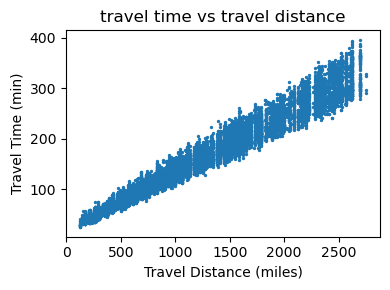

In [6]:
# ANSWER CELL

# Do not modify these lines for grading purposes
import matplotlib.pyplot as plt
from matplotlib.collections import PathCollection

# create figure and axes
fig_1, ax_1 = plt.subplots(nrows=1, ncols=1, figsize=(4,3))

# create scatter plot
plt.scatter(travel_distance, travel_time, s=2) # SOLUTION

# Label the axes
# BEGIN SOLUTION
ax_1.set(title = 'travel time vs travel distance',
         xlabel = 'Travel Distance (miles)',
         ylabel = 'Travel Time (min)')
# END SOLUTION

# Display the plot
plt.tight_layout()
plt.show()

In [7]:
""" # BEGIN TEST CONFIG
points: 0
failure_message: Make sure to create a figure with 1 axes and assign them to "fig_1" and "ax_1".
""" # END TEST CONFIG

# Check figure was created
assert type(fig_1).__name__ == 'Figure'

# Check axes was created
assert type(ax_1).__name__ == 'Axes'

In [8]:
""" # BEGIN TEST CONFIG
points: 0
failure_message: Make sure you are plotting using plt.scatter().
""" # END TEST CONFIG

# Check scatterplot was created
assert isinstance(ax_1.collections[0], PathCollection)

In [9]:
""" # BEGIN TEST CONFIG
points: 0.4
failure_message: Make sure to plot travel time on y-axis and travel distance on x-axis.
""" # END TEST CONFIG

assert get_hash(len(ax_1.collections[0].get_offsets()[:,1])) == '73c7f51cc11fcfe48b44cf5e412fe1e4'
assert get_hash(sum(ax_1.collections[0].get_offsets()[:,1])) == 'fecc32238853cf4eb3ccb3843311bf74'
assert get_hash(len(ax_1.collections[0].get_offsets()[:,0])) == '73c7f51cc11fcfe48b44cf5e412fe1e4'
assert get_hash(sum(ax_1.collections[0].get_offsets()[:,0])) == '40cae5f136b9314c8af84129435a7695'

In [10]:
""" # BEGIN TEST CONFIG
points: 0.05
failure_message: Check y-axis label.
""" # END TEST CONFIG

# Check ylabel 
keywords = ['TRAVEL', 'TIME', 'MIN']
assert all(word in ax_1.get_ylabel().upper() for word in keywords)

In [11]:
""" # BEGIN TEST CONFIG
points: 0.05
failure_message: Check x-axis label.
""" # END TEST CONFIG

# Check xlabel 
keywords = ['TRAVEL', 'DISTANCE', 'MILES']
assert all(word in ax_1.get_xlabel().upper() for word in keywords)

<font color='red'>**Question 1.2.**</font> Based on the scatter plot above, what observations can you make? Assign ALL that apply to the variable `q1_2`. (0.5 pts)

**A.** There appears to be a positive linear association between `travel_time` and `travel_distance` \
**B.** There appears to be a negative linear association between `travel_time` and `travel_distance` \
**C.** There appears to be no  association between `travel_time` and `travel_distance` \
**D.** There appears to be higher variability in travel time at higher travel distances \
**E.** There appears to be less variability in travel time at higher travel distances \
**F.** There appears to be constant variability in travel time regardless of travel distance\
**G.** There appears to be a non linear association between `travel_time` and `travel_distance`

Answer in the next cell. Add each selected choice as a string and separate each two answer choices by a comma. For example, if you want to select `"A"` and `"B"`, your answer should be `"A", "B"`.\
Assign your answer to the given variable.
Remember to put quotes around each answer choice.

**Note that the test for this question will be a hidden test. Meaning, you will NOT be able to know whether your answer is correct or not by running the `grader.check()` cell.**

In [12]:
# ANSWER CELL

q1_2 = "A", "D" # SOLUTION
q1_2

('A', 'D')

In [13]:
""" # BEGIN TEST CONFIG
points: 0
success_message: Correct answer format. Note that the actual test is hidden.
failure_message: Incorrect answer format. Make sure you only have the letter of your answer choice in quotes and answers are separated by commas.
""" # END TEST CONFIG

assert isinstance(q1_2, (tuple, str))
assert all(isinstance(option, str) for option in q1_2)
assert all(len(option) == 1 for option in q1_2)

In [14]:
""" # BEGIN TEST CONFIG
points: 0.1
hidden: true
""" # END TEST CONFIG

assert get_hash("A" in q1_2 or "a" in q1_2) == 'f827cf462f62848df37c5e1e94a4da74'
assert get_hash(len(ax_1.collections[0].get_offsets()[:,1])) == '73c7f51cc11fcfe48b44cf5e412fe1e4'

In [15]:
""" # BEGIN TEST CONFIG
points: 0.06
hidden: true
""" # END TEST CONFIG

assert get_hash("B" in q1_2 or "b" in q1_2) == 'f8320b26d30ab433c5a54546d21f414c'
assert get_hash(len(ax_1.collections[0].get_offsets()[:,1])) == '73c7f51cc11fcfe48b44cf5e412fe1e4'

In [16]:
""" # BEGIN TEST CONFIG
points: 0.06
hidden: true
""" # END TEST CONFIG

assert get_hash("C" in q1_2 or "c" in q1_2) == 'f8320b26d30ab433c5a54546d21f414c'
assert get_hash(len(ax_1.collections[0].get_offsets()[:,1])) == '73c7f51cc11fcfe48b44cf5e412fe1e4'

In [17]:
""" # BEGIN TEST CONFIG
points: 0.1
hidden: true
""" # END TEST CONFIG

assert get_hash("D" in q1_2 or "d" in q1_2) == 'f827cf462f62848df37c5e1e94a4da74'
assert get_hash(len(ax_1.collections[0].get_offsets()[:,1])) == '73c7f51cc11fcfe48b44cf5e412fe1e4'

In [18]:
""" # BEGIN TEST CONFIG
points: 0.06
hidden: true
""" # END TEST CONFIG

assert get_hash("E" in q1_2 or "e" in q1_2) == 'f8320b26d30ab433c5a54546d21f414c'
assert get_hash(len(ax_1.collections[0].get_offsets()[:,1])) == '73c7f51cc11fcfe48b44cf5e412fe1e4'

In [19]:
""" # BEGIN TEST CONFIG
points: 0.06
hidden: true
""" # END TEST CONFIG

assert get_hash("F" in q1_2 or "f" in q1_2) == 'f8320b26d30ab433c5a54546d21f414c'
assert get_hash(len(ax_1.collections[0].get_offsets()[:,1])) == '73c7f51cc11fcfe48b44cf5e412fe1e4'

In [20]:
""" # BEGIN TEST CONFIG
points: 0.06
hidden: true
""" # END TEST CONFIG

assert get_hash("G" in q1_2 or "g" in q1_2) == 'f8320b26d30ab433c5a54546d21f414c'
assert get_hash(len(ax_1.collections[0].get_offsets()[:,1])) == '73c7f51cc11fcfe48b44cf5e412fe1e4'

### Linear Regression Using `scikit-learn`

We will use the `scikit-learn` package to perform linear regression. There are other packages as well, but this is one of the most commonly used packages and is also a widely used Python library for machine learning, built on top of NumPy and some other packages. You will specifically use the class `sklearn.linear_model.LinearRegression` to perform linear regression. You already loaded this class in the second code cell.

Before we apply linear regression, we must have our data sets in the correct format. Specifically, you must:
1. Convert the data sets from Pandas to NumPy array
2. Format the `x` variable such that it is two-dimensional, or more precisely, it must have one column and many rows

Run the code cell below to properly format the data sets for regression.

In [21]:
# Format the data sets
travel_time = np.array(travel_time) # convert from pandas to numpy array
travel_distance = np.array(travel_distance) # convert from pandas to numpy array

travel_distance = travel_distance.reshape(-1, 1) # format the x variable such that it is two-dimensional with 1 column

# Output the arrays
print('Travel Distance: shape '+ str(travel_distance.shape))
print(travel_distance)

print('\n\n Travel Time: shape '+ str(travel_time.shape))
print(travel_time)

Travel Distance: shape (18936, 1)
[[ 732.129795]
 [1907.434669]
 [1033.925949]
 ...
 [1769.842435]
 [1272.624121]
 [ 841.089583]]


 Travel Time: shape (18936,)
[ 92 269 156 ... 188 147 116]


As evident, `travel_distance` has two dimensions: shape (18936, 1), while `travel_time` has a single dimension: shape (18936, ). This format is required to be able to use `sklearn.linear_model.LinearRegression`.

The next step is to create a linear regression model and fit it using the existing data. The statement below creates the variable `model` as an instance of `LinearRegression`, which will represent the regression model.

Run the code cell below to create the variable `model`.

In [22]:
# Create the variable model

model = LinearRegression()

It's time to fit a linear regression model to the data. We would like to create the following model:

`travel_time` = $\beta_0 + \beta_1 \times$`travel_distance`

This can be done using the variable `model` that you defined in the code cell above. Specifically, `model.fit(x, y)` will calculate the optimal estimates $\hat{\beta_0}$ and $\hat{\beta_1}$ that result in a regression line that is closer to the input data `(x, y)` than any other line.

Since we will create several models, let's save this one as `model1`.

Run the code below to perform a linear regression between `travel_distance` and `travel_time`. Note that the order of the variables in `model.fit()` is important. The first variable should be the independent variable `x` and the second one should be the dependent variable `y`.

The code cell below will not print any output. We will see how to get the outputs next.

In [23]:
# fit your linear regresseion model here

model1 = model.fit(travel_distance, travel_time)

Once you have your fitted model, you can get the results to check whether the model is satisfactory.

The estimated intercept $\hat{\beta_0}$ is obtained using `model1.intercept_`

The estimated slope $\hat{\beta_1}$ is obtained using `model1.coef_[0]`

Note that we are using `model1.<>` because we saved our model in this case as variable `model1`. If we used a different variable name, we would access the intercept and coefficients using that variable name. Always ensure consistency in variable names to avoid confusion and errors in your code.

<font color='red'>**Question 2.0.**</font> What is the estimated intercept $\hat{\beta_0}$ and estimated slope $\hat{\beta_1}$? Assign your answers to variables `beta_0` and `beta_1`, respectively. Do not just manually type the numeric answers. Use Python expressions that return the desired answer and assign the expression to the variable. (0.5 pts)

In [24]:
# ANSWER CELL

beta_0 = model1.intercept_ # SOLUTION
beta_1 = model1.coef_[0] # SOLUTION

print(f'Intercept: {beta_0:.3f} min' if not isinstance(beta_0, type(Ellipsis)) else None)
print(f'Slope: {beta_1:.3f} min/miles' if not isinstance(beta_1, type(Ellipsis)) else None)

Intercept: 18.590 min
Slope: 0.115 min/miles


In [25]:
""" # BEGIN TEST CONFIG
points: 0.25
failure_message: Incorrect beta_0.
""" # END TEST CONFIG

assert get_hash(round(beta_0,10)) == 'd85344397d8448bec50b0b931d1a5479'

In [26]:
""" # BEGIN TEST CONFIG
points: 0.25
failure_message: Incorrect beta_1.
""" # END TEST CONFIG

assert get_hash(round(beta_1,10)) == 'e06c1bad529a5863180a8e4f631d803a'

<font color='red'>**Question 2.1.**</font> What is the equation of the regression line between `travel_time` and `travel_distance`? Assign your answer to the variable `q2_1` as a string. (0.25 pts)

**A.** `travel_distance` = $0.115+18.59 \times$ `travel_time` \
**B.** `travel_time` = $0.115+18.59 \times$ `travel_distance` \
**C.** `travel_time` = $18.59+0.115 \times$ `travel_distance` \
**D.** `travel_distance` = $18.59+0.115 \times$ `travel_time`

Your answer should be a string, e.g., `"A"`, `"B"`, etc.\
Remember to put quotes around your answer choice.

**Note that the test for this question will be a hidden test. Meaning, you will NOT be able to know whether your answer is correct or not by running the `grader.check()` cell.**

In [27]:
# ANSWER CELL

q2_1 = "C" # SOLUTION
q2_1

'C'

In [28]:
""" # BEGIN TEST CONFIG
points: 0
success_message: Correct answer format. Note that the actual test is hidden.
failure_message: Incorrect answer format. Make sure you only have the letter of your answer choice in quotes.
""" # END TEST CONFIG

assert len(q2_1) == 1
assert isinstance(q2_1, str)

In [29]:
""" # BEGIN TEST CONFIG
points: 0.25
hidden: true
""" # END TEST CONFIG

assert get_hash(q2_1.upper()) == '0d61f8370cad1d412f80b84d143e1257'
assert get_hash(round(beta_1,10)) == 'e06c1bad529a5863180a8e4f631d803a'

<font color='red'>**Question 2.2.**</font> What does the estimated slope $\hat{\beta_1}$ represent in this case? Assign ALL that apply to the variable `q2_2`. (0.5 pts)

**A.** The average change in travel time for every unit increase in travel distance \
**B.** The average change in travel distance for every unit increase in travel time \
**C.** The average change in travel time for any increase in travel distance \
**D.** The average change in travel distance for any increase in travel time \
**E.** Its reciprocal is the average speed of domestic flights in the U.S.

Answer in the next cell. Add each selected choice as a string and separate each two answer choices by a comma. For example, if you want to select `"A"` and `"B"`, your answer should be `"A", "B"`.\
Assign your answer to the given variable.
Remember to put quotes around each answer choice.

In [30]:
# ANSWER CELL

q2_2 = "A", "E" # SOLUTION
q2_2

('A', 'E')

In [31]:
""" # BEGIN TEST CONFIG
points: 0
success_message: Correct answer format.
failure_message: Incorrect answer format. Make sure you only have the letter of your answer choice in quotes and answers are separated by commas.
""" # END TEST CONFIG

assert isinstance(q2_2, (tuple, str))
assert all(isinstance(option, str) for option in q2_2)
assert all(len(option) == 1 for option in q2_2)

In [32]:
""" # BEGIN TEST CONFIG
points: 0.05
failure_message: Incorrect answer. Slope is the change in y for every unit increase in x.
""" # END TEST CONFIG

assert not any('9d5ed678fe57bcca610140957afab571' == get_hash(option.upper()) for option in q2_2)
assert get_hash(round(beta_1,10)) == 'e06c1bad529a5863180a8e4f631d803a'

In [33]:
""" # BEGIN TEST CONFIG
points: 0.05
failure_message: Incorrect answer. Slope is the change in y for every unit increase in x.
""" # END TEST CONFIG

assert not any('0d61f8370cad1d412f80b84d143e1257' == get_hash(option.upper()) for option in q2_2)
assert get_hash(round(beta_1,10)) == 'e06c1bad529a5863180a8e4f631d803a'

In [34]:
""" # BEGIN TEST CONFIG
points: 0.05
failure_message: Incorrect answer. Slope is the change in y for every unit increase in x.
""" # END TEST CONFIG

assert not any('f623e75af30e62bbd73d6df5b50bb7b5' == get_hash(option.upper()) for option in q2_2)
assert get_hash(round(beta_1,10)) == 'e06c1bad529a5863180a8e4f631d803a'

In [35]:
""" # BEGIN TEST CONFIG
points: 0.175
failure_message: Incorrect answer. Slope is the change in y for every unit increase in x.
""" # END TEST CONFIG

assert any('7fc56270e7a70fa81a5935b72eacbe29' == get_hash(option.upper()) for option in q2_2)
assert get_hash(round(beta_1,10)) == 'e06c1bad529a5863180a8e4f631d803a'

In [36]:
""" # BEGIN TEST CONFIG
points: 0.175
failure_message: Incorrect answer. Look at the units of the slope. What would be the units of its reciprocal?
""" # END TEST CONFIG

assert any('3a3ea00cfc35332cedf6e5e9a32e94da' == get_hash(option.upper()) for option in q2_2)
assert get_hash(round(beta_1,10)) == 'e06c1bad529a5863180a8e4f631d803a'

Once you have fitted your model using the training data, you can use it to make predictions on existing or new data. This can be achieved using the `predict()` method of the model object. The basic syntax is:

`predicted_y = model1.predict(new_x)`

Note that we are using `model1.predict()` because we saved our model in this case as variable `model1`. If we used a different variable name, we would use that variable name. Always ensure consistency in variable names to avoid confusion and errors in your code.

<font color='red'>**Question 3.0.**</font> In the same plot, show the data and the regression line. Follow these steps (0.75 pts)

1. Estimate travel time for the existing `travel_distance` values using the regression model. Save this as `travel_time_pred`.
2. Create a scatter plot of the original data sets
3. In the same scatter plot, plot the regression line using the estimated travel time. Show the regression line using <font color='red'>**red**</font> color by specifying `c='r'`.
4. Set the x-axis label to `'Travel Distance (miles)'` and the y-axis label to `'Travel Time (min)'`.

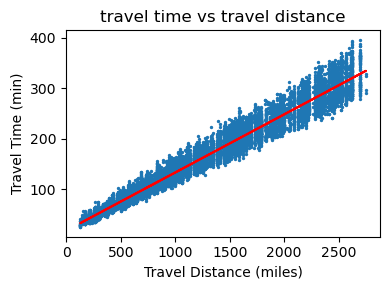

In [37]:
# ANSWER CELL

# Do not modify these lines for grading purposes
import matplotlib.pyplot as plt
from matplotlib.collections import PathCollection
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors

# get the predicted travel time at the values of travel_distance
travel_time_pred = model1.predict(travel_distance) # SOLUTION

# create figure and axes
fig_2, ax_2 = plt.subplots(nrows=1, ncols=1, figsize=(4,3))

# create scatterplot of the observed data
plt.scatter(travel_distance, travel_time, s=2) # SOLUTION

# plot the regression line in red
plt.plot(travel_distance, travel_time_pred, 'r') # SOLUTION

# Label the axes
# BEGIN SOLUTION
ax_2.set(title = 'travel time vs travel distance',
         xlabel = 'Travel Distance (miles)',
         ylabel = 'Travel Time (min)')
# END SOLUTION

# Display the plot
plt.tight_layout()
plt.show()

In [38]:
""" # BEGIN TEST CONFIG
points: 0
failure_message: Make sure to create a figure with 1 axes and assign them to "fig_2" and "ax_2".
""" # END TEST CONFIG

# Check figure was created
assert type(fig_2).__name__ == 'Figure'

# Check axes was created
assert type(ax_2).__name__ == 'Axes'

In [39]:
""" # BEGIN TEST CONFIG
points: 0
failure_message: Make sure you are plotting the data using plt.scatter().
""" # END TEST CONFIG

# Check scatterplot was created
assert isinstance(ax_2.collections[0], PathCollection)

In [40]:
""" # BEGIN TEST CONFIG 
points: 0
failure_message: Make sure you are plotting the regression line using plt.plot().
""" # END TEST CONFIG

# Check PDF was plotted
assert isinstance(ax_2.lines[0], Line2D)

In [41]:
""" # BEGIN TEST CONFIG
points: 0.2
failure_message: Incorrect travel_time_pred. You need to use the function model1.predict()
""" # END TEST CONFIG

assert get_hash(len(travel_time_pred)) == '73c7f51cc11fcfe48b44cf5e412fe1e4'
assert get_hash(travel_time_pred.shape) == 'dca6f92577035f21406621b702fda244'
assert get_hash(int(sum(travel_time_pred))) == '4d6aae3100d82b4ea191cf83b86917d4'

In [42]:
""" # BEGIN TEST CONFIG
points: 0.1
failure_message: Make sure to plot travel time on x-axis and travel distance on y-axis.
""" # END TEST CONFIG

assert get_hash(len(ax_2.collections[0].get_offsets()[:,1])) == '73c7f51cc11fcfe48b44cf5e412fe1e4'
assert get_hash(sum(ax_2.collections[0].get_offsets()[:,1])) == 'fecc32238853cf4eb3ccb3843311bf74'
assert get_hash(len(ax_2.collections[0].get_offsets()[:,0])) == '73c7f51cc11fcfe48b44cf5e412fe1e4'
assert get_hash(sum(ax_2.collections[0].get_offsets()[:,0])) == '40cae5f136b9314c8af84129435a7695'

In [43]:
""" # BEGIN TEST CONFIG
points: 0.1
failure_message: Check y-axis label.
""" # END TEST CONFIG

# Check ylabel 
keywords = ['TRAVEL', 'TIME', 'MIN']
assert all(word in ax_2.get_ylabel().upper() for word in keywords)

In [44]:
""" # BEGIN TEST CONFIG
points: 0.1
failure_message: Check x-axis label.
""" # END TEST CONFIG

# Check xlabel 
keywords = ['TRAVEL', 'DISTANCE', 'MILES']
assert all(word in ax_2.get_xlabel().upper() for word in keywords)

In [45]:
""" # BEGIN TEST CONFIG 
points: 0.2
failure_message: Check the arguments of plt.plot()
""" # END TEST CONFIG

# Check x data of regression line
assert get_hash(sum(ax_2.lines[0].get_xdata())) == '40cae5f136b9314c8af84129435a7695'
assert get_hash(len(ax_2.lines[0].get_xdata())) == '73c7f51cc11fcfe48b44cf5e412fe1e4'

# Check y data of regression line
assert get_hash(int(sum(ax_2.lines[0].get_ydata()))) == '4d6aae3100d82b4ea191cf83b86917d4'
assert get_hash(len(ax_2.lines[0].get_ydata())) == '73c7f51cc11fcfe48b44cf5e412fe1e4'

In [46]:
""" # BEGIN TEST CONFIG 
points: 0.05
failure_message: Show the regression line in red.
""" # END TEST CONFIG

# Check line color
assert mcolors.same_color(ax_2.lines[0].get_color(), 'r')

### Goodness of Fit using `model.score()`

Python has direct functions to compute the coefficient of determination, $r^2$, among other summaries. For example, you can directly compute $r^2$ using the `score()` method of the model object. The basic syntax is:

`r2 = model.score(x, y)`

where `x` and `y` represent the observed (input) values of the independent and dependent variables, respectively.

<font color='red'>**Question 4.0.**</font> Calculate the coefficient of determination, $r^2$, using the `score()` method for the regression model between `travel_distance` and `travel_time`. Assign your answer to `q4_0`. Do not just manually type the numeric answer. Use Python expressions that return the desired answer and assign the expression to the variable. (0.25 pts)

In [47]:
# ANSWER CELL

# calculate r^2 using score() method
q4_0 = model.score(travel_distance, travel_time) # SOLUTION

print(f'r^2: {q4_0:.3f}' if not isinstance(q4_0, type(Ellipsis)) else None)

r^2: 0.967


In [48]:
""" # BEGIN TEST CONFIG
points: 0.25
failure_message: Incorrect answer. You need to use the variable names of the input data.
""" # END TEST CONFIG

assert get_hash(round(q4_0,10)) == 'eb9ab0df20c4e00594fe0dbd93a44cb8'

<font color='red'>**Question 4.1.**</font> What can you say about the model based on the value of $r^2$? Assign ALL that apply to the variable `q4_1`. (0.75 pts)

**A.** 96.7% of the variability in travel time can be explained by the variability in travel distance \
**B.** 0.967% of the variability in travel time can be explained by the variability in travel distance \
**C.** 98.3% of the variability in travel time can be explained by the variability in travel distance \
**D.** 0.983% of the variability in travel time can be explained by the variability in travel distance \
**E.** The model has a good fit to the data \
**F.** The model has a poor fit to the data \
**G.** None of the variability in travel time can be explained by the variability in travel distance \
**H.** The sample correlation coefficient is approximately 0.983 \
**I.** We cannot determine the sample correlation coefficient based on $r^2$

Answer in the next cell. Add each selected choice as a string and separate each two answer choices by a comma. For example, if you want to select `"A"` and `"B"`, your answer should be `"A", "B"`.\
Assign your answer to the given variable.
Remember to put quotes around each answer choice.

In [49]:
# ANSWER CELL

q4_1 = "A", "E", "H" # SOLUTION
q4_1

('A', 'E', 'H')

In [50]:
""" # BEGIN TEST CONFIG
points: 0
success_message: Correct answer format.
failure_message: Incorrect answer format. Make sure you only have the letter of your answer choice in quotes and answers are separated by commas.
""" # END TEST CONFIG

assert isinstance(q4_1, (tuple, str))
assert all(isinstance(option, str) for option in q4_1)
assert all(len(option) == 1 for option in q4_1)

In [51]:
""" # BEGIN TEST CONFIG
points: 0.05
failure_message: Incorrect answer. r2 represents the fraction of the total variability in y that can be explained by the variability in x.
""" # END TEST CONFIG

assert not any('9d5ed678fe57bcca610140957afab571' == get_hash(option.upper()) for option in q4_1)
assert get_hash(round(q4_0,10)) == 'eb9ab0df20c4e00594fe0dbd93a44cb8'

In [52]:
""" # BEGIN TEST CONFIG
points: 0.05
failure_message: Incorrect answer. r2 represents the fraction of the total variability in y that can be explained by the variability in x.
""" # END TEST CONFIG

assert not any('0d61f8370cad1d412f80b84d143e1257' == get_hash(option.upper()) for option in q4_1)
assert get_hash(round(q4_0,10)) == 'eb9ab0df20c4e00594fe0dbd93a44cb8'

In [53]:
""" # BEGIN TEST CONFIG
points: 0.05
failure_message: Incorrect answer. r2 represents the fraction of the total variability in y that can be explained by the variability in x.
""" # END TEST CONFIG

assert not any('f623e75af30e62bbd73d6df5b50bb7b5' == get_hash(option.upper()) for option in q4_1)
assert get_hash(round(q4_0,10)) == 'eb9ab0df20c4e00594fe0dbd93a44cb8'

In [54]:
""" # BEGIN TEST CONFIG
points: 0.05
failure_message: Incorrect answer. Is r2 close to 1?
""" # END TEST CONFIG

assert not any('800618943025315f869e4e1f09471012' == get_hash(option.upper()) for option in q4_1)
assert get_hash(round(q4_0,10)) == 'eb9ab0df20c4e00594fe0dbd93a44cb8'

In [55]:
""" # BEGIN TEST CONFIG
points: 0.05
failure_message: Incorrect answer. r2 represents the fraction of the total variability in y that can be explained by the variability in x.
""" # END TEST CONFIG

assert not any('dfcf28d0734569a6a693bc8194de62bf' == get_hash(option.upper()) for option in q4_1)
assert get_hash(round(q4_0,10)) == 'eb9ab0df20c4e00594fe0dbd93a44cb8'

In [56]:
""" # BEGIN TEST CONFIG
points: 0.05
failure_message: Incorrect answer. How can you obtain correlation, r, from r2?
""" # END TEST CONFIG

assert not any('dd7536794b63bf90eccfd37f9b147d7f' == get_hash(option.upper()) for option in q4_1)
assert get_hash(round(q4_0,10)) == 'eb9ab0df20c4e00594fe0dbd93a44cb8'

In [57]:
""" # BEGIN TEST CONFIG
points: 0.15
failure_message: Incorrect answer. r2 represents the fraction of the total variability in y that can be explained by the variability in x.
""" # END TEST CONFIG

assert any('7fc56270e7a70fa81a5935b72eacbe29' == get_hash(option.upper()) for option in q4_1)
assert get_hash(round(q4_0,10)) == 'eb9ab0df20c4e00594fe0dbd93a44cb8'

In [58]:
""" # BEGIN TEST CONFIG
points: 0.15
failure_message: Incorrect answer. Is r2 close to 1?
""" # END TEST CONFIG

assert any('3a3ea00cfc35332cedf6e5e9a32e94da' == get_hash(option.upper()) for option in q4_1)
assert get_hash(round(q4_0,10)) == 'eb9ab0df20c4e00594fe0dbd93a44cb8'

In [59]:
""" # BEGIN TEST CONFIG
points: 0.15
failure_message: Incorrect answer. How can you obtain correlation, r, from r2?
""" # END TEST CONFIG

assert any('c1d9f50f86825a1a2302ec2449c17196' == get_hash(option.upper()) for option in q4_1)
assert get_hash(round(q4_0,10)) == 'eb9ab0df20c4e00594fe0dbd93a44cb8'

### Diagnostics

The last step is to check the assumptions of our model. Recall that linear regression is based on the following assumptions:

1. Linear relationship between X and Y
2. Independent error terms (and therefore, independent observations)
3. Normally distributed error terms
4. Equal variance of the error terms along regression line

If the model is appropriate for the data, the observed residuals should reflect these properties. Recall that the residuals are the actual values minus the estimated values:

$$e_i = y_i - \hat{y_i}$$

* You should have already computed the estimated values and saved them as `travel_time_pred`

<font color='red'>**Question 5.0.**</font> In the cell below, compute the residuals for our model. Assign your answer to `residuals`. Do not just manually type the numeric answer. Use Python expressions that return the desired answer and assign the expression to the variable. (0.25 pts)

In [60]:
# ANSWER CELL

residuals = travel_time - travel_time_pred # SOLUTION

print(f'Residuals: {residuals.round(3)} min' if not isinstance(residuals, type(Ellipsis)) else None)

Residuals: [-10.687  31.309  18.646 ... -33.886 -17.772   0.797] min


In [61]:
""" # BEGIN TEST CONFIG
points: 0.25
failure_message: Incorrect answer.
""" # END TEST CONFIG

assert get_hash(len(residuals)) == '73c7f51cc11fcfe48b44cf5e412fe1e4'
assert get_hash(round(sum(residuals), 10)) == '426de3c03cd11215f086a47662e9fedd'

### Residual Plot

Assumptions 1, 2, and 4 can be checked by plotting the residuals against the x values or the estimated values.

<font color='red'>**Question 5.1.**</font> Create a scatterplot of the residuals against the estimated values (saved as `travel_time_pred`). Follow these steps: (0.5 pts)
1. Plot the residuals against the estimated values `travel_time_pred`. To control the size of the markers, you can specify `plt.scatter(x,y,s=...)`
2. Plot a horizontal line corresponding to residual of 0 using `plt.axhline(y=0, color='gray')`
3. Set the x-axis label to `'Predicted Values (min)'` and the y-axis label to `'Residuals (min)'`

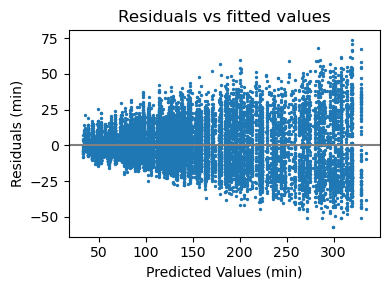

In [62]:
# ANSWER CELL

# Do not modify these lines for grading purposes
import matplotlib.pyplot as plt
from matplotlib.collections import PathCollection
from matplotlib.lines import Line2D

# create figure and axes
fig_3, ax_3 = plt.subplots(nrows=1, ncols=1, figsize=(4,3))

# create scatterplot of the residuals
plt.scatter(travel_time_pred, residuals, s=2) # SOLUTION

# plot a horizontal line at y=0
plt.axhline(y=0, color='gray') # SOLUTION

# Label the axes
# BEGIN SOLUTION
ax_3.set(title = 'Residuals vs fitted values',
         ylabel = 'Residuals (min)',
         xlabel = 'Predicted Values (min)')
# END SOLUTION

# Display the plot
plt.tight_layout()
plt.show()

In [63]:
""" # BEGIN TEST CONFIG
points: 0
failure_message: Make sure to create a figure with 1 axes and assign them to "fig_3" and "ax_3".
""" # END TEST CONFIG

# Check figure was created
assert type(fig_3).__name__ == 'Figure'

# Check axes was created
assert type(ax_3).__name__ == 'Axes'

In [64]:
""" # BEGIN TEST CONFIG
points: 0
failure_message: Make sure you are plotting the data using plt.scatter().
""" # END TEST CONFIG

# Check scatterplot was created
assert isinstance(ax_3.collections[0], PathCollection)

In [65]:
""" # BEGIN TEST CONFIG 
points: 0
failure_message: Make sure you are plotting the regression line using plt.axhline().
""" # END TEST CONFIG

# Check PDF was plotted
assert isinstance(ax_3.lines[0], Line2D)

In [66]:
""" # BEGIN TEST CONFIG
points: 0.3
failure_message: Make sure to plot predicted values on x-axis and residual on y-axis.
""" # END TEST CONFIG

assert get_hash(len(ax_3.collections[0].get_offsets()[:,1])) == '73c7f51cc11fcfe48b44cf5e412fe1e4'
assert get_hash(round(sum(ax_3.collections[0].get_offsets()[:,1]), 10)) == '426de3c03cd11215f086a47662e9fedd'
assert get_hash(len(ax_3.collections[0].get_offsets()[:,0])) == '73c7f51cc11fcfe48b44cf5e412fe1e4'
assert get_hash(int(sum(ax_3.collections[0].get_offsets()[:,0]))) == '4d6aae3100d82b4ea191cf83b86917d4'

In [67]:
""" # BEGIN TEST CONFIG 
points: 0.1
failure_message: Check the arguments of plt.plot()
""" # END TEST CONFIG

# Check x data of horizontal line
assert get_hash(sum(ax_3.lines[0].get_xdata())) == 'c4ca4238a0b923820dcc509a6f75849b'
assert get_hash(len(ax_3.lines[0].get_xdata())) == 'c81e728d9d4c2f636f067f89cc14862c'

# Check y data of horizontal line
assert get_hash(sum(ax_3.lines[0].get_ydata())) == 'cfcd208495d565ef66e7dff9f98764da'
assert get_hash(len(ax_3.lines[0].get_ydata())) == 'c81e728d9d4c2f636f067f89cc14862c'

In [68]:
""" # BEGIN TEST CONFIG
points: 0.05
failure_message: Check x-axis label.
""" # END TEST CONFIG

# Check xlabel 
keywords = ['PREDICTED', 'VALUES', 'MIN']
assert all(word in ax_3.get_xlabel().upper() for word in keywords)

In [69]:
""" # BEGIN TEST CONFIG
points: 0.05
failure_message: Check y-axis label.
""" # END TEST CONFIG

# Check ylabel 
keywords = ['RESIDUALS', 'MIN']
assert all(word in ax_3.get_ylabel().upper() for word in keywords)

### Residual Histogram

Assumption 3 (normality) can be checked by plotting a histogram of the residuals. You can plot a theoretical normal pdf along with the histogram, or simply visually assess whether the distribution of the residuals appears to have a bell-curve shape. You can also plot a Q-Q plot of the residuals. However, we will only focus on plotting a histogram in this case. 

<font color='red'>**Question 5.2.**</font> In the code cell below, plot a frequency histogram of `residuals` with `bins=12` and assign it to the variable `histogram`. Set the x-axis label to `'Residuals (min)'` and the y-axis label to `'Frequency'`. (0.5 pts)

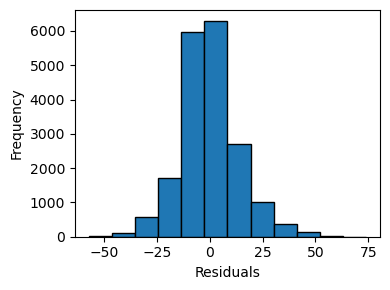

In [70]:
# ANSWER CELL

# Do not modify this line for grading purposes
import matplotlib.pyplot as plt

# create figure and axes
fig_4, ax_4 = plt.subplots(nrows=1, ncols=1, figsize=(4,3))

# Plot frequency histogram. Assign the plot to the variable histogram.
histogram = plt.hist(residuals, bins=12, ec='k') # SOLUTION

# Label the axes
# BEGIN SOLUTION
ax_4.set(ylabel = 'Frequency',
         xlabel = 'Residuals')
# END SOLUTION

# Display the plot
plt.tight_layout()
plt.show()

In [71]:
""" # BEGIN TEST CONFIG
points: 0
failure_message: Make sure to create a figure with 1 axes and assign them to "fig_4" and "ax_4".
""" # END TEST CONFIG

# Check figure was created
assert type(fig_4).__name__ == 'Figure'

# Check axes was created
assert type(ax_4).__name__ == 'Axes'

In [72]:
""" # BEGIN TEST CONFIG
points: 0
failure_message: Make sure to save the histogram as object "histogram".
""" # END TEST CONFIG

# Check histogram was created
assert isinstance(histogram, tuple)
assert len(histogram) == 3

In [73]:
""" # BEGIN TEST CONFIG 
points: 0.3
failure_message: Check histogram data. Make sure you are specifying the correct bins.
""" # END TEST CONFIG

# Check relative frequency histogram
assert get_hash(len(histogram[0])) == 'c20ad4d76fe97759aa27a0c99bff6710'
assert get_hash(len(histogram[1])) == 'c51ce410c124a10e0db5e4b97fc2af39'
assert get_hash(sum(histogram[0])) == 'a4d6c0d686afe2415b6833a6e995dc3b'
assert get_hash(round(sum(histogram[1]), 10)) == '04d5e91d2277ef7a921bda7df119b2fa'

In [74]:
""" # BEGIN TEST CONFIG
points: 0.1
failure_message: Check x-axis label.
""" # END TEST CONFIG

# Check xlabel 
keywords = ['RESIDUAL']
assert all(word in ax_4.get_xlabel().upper() for word in keywords)

In [75]:
""" # BEGIN TEST CONFIG
points: 0.1
failure_message: Check y-axis label.
""" # END TEST CONFIG

# Check ylabel 
keywords = ['FREQUENCY']
assert all(word in ax_4.get_ylabel().upper() for word in keywords)

<font color='red'>**Question 5.3.**</font> Which assumption(s) appear(s) to be violated, if any, based on your plots? Assign ALL that apply to the variable `q5_3`. (0.75 pts)

**A.** Assumption of linear relationship \
**B.** Assumption of equal variance \
**C.** Assumption of independent errors/observations \
**D.** Assumption of normally distirbuted errors \
**E.** None

Answer in the next cell. Add each selected choice as a string and separate each two answer choices by a comma. For example, if you want to select `"A"` and `"B"`, your answer should be `"A", "B"`.\
Assign your answer to the given variable.
Remember to put quotes around each answer choice.

In [76]:
# ANSWER CELL

q5_3 = "B" # SOLUTION
q5_3

'B'

In [77]:
""" # BEGIN TEST CONFIG
points: 0
success_message: Correct answer format.
failure_message: Incorrect answer format. Make sure you only have the letter of your answer choice in quotes and answers are separated by commas.
""" # END TEST CONFIG

assert isinstance(q5_3, (tuple, str))
assert all(isinstance(option, str) for option in q5_3)
assert all(len(option) == 1 for option in q5_3)

In [78]:
""" # BEGIN TEST CONFIG
points: 0.15
failure_message: Incorrect answer. Do you see a funnel shape in the residuals scatterplot?
""" # END TEST CONFIG

assert any('9d5ed678fe57bcca610140957afab571' == get_hash(option.upper()) for option in q5_3)
assert get_hash(len(histogram[0])) == 'c20ad4d76fe97759aa27a0c99bff6710'
assert get_hash(len(ax_3.collections[0].get_offsets()[:,1])) == '73c7f51cc11fcfe48b44cf5e412fe1e4'

In [79]:
""" # BEGIN TEST CONFIG
points: 0.15
failure_message: Incorrect answer. Do you see a curved shape in the residuals scatterplot?
""" # END TEST CONFIG

assert not any('7fc56270e7a70fa81a5935b72eacbe29' == get_hash(option.upper()) for option in q5_3)
assert get_hash(len(histogram[0])) == 'c20ad4d76fe97759aa27a0c99bff6710'
assert get_hash(len(ax_3.collections[0].get_offsets()[:,1])) == '73c7f51cc11fcfe48b44cf5e412fe1e4'

In [80]:
""" # BEGIN TEST CONFIG
points: 0.15
failure_message: Incorrect answer. Do neighboring residuals have similar values?
""" # END TEST CONFIG

assert not any('0d61f8370cad1d412f80b84d143e1257' == get_hash(option.upper()) for option in q5_3)
assert get_hash(len(histogram[0])) == 'c20ad4d76fe97759aa27a0c99bff6710'
assert get_hash(len(ax_3.collections[0].get_offsets()[:,1])) == '73c7f51cc11fcfe48b44cf5e412fe1e4'

In [81]:
""" # BEGIN TEST CONFIG
points: 0.15
failure_message: Incorrect answer. Does the histogram follow a bell-curved shape?
""" # END TEST CONFIG

assert not any('f623e75af30e62bbd73d6df5b50bb7b5' == get_hash(option.upper()) for option in q5_3)
assert get_hash(len(histogram[0])) == 'c20ad4d76fe97759aa27a0c99bff6710'
assert get_hash(len(ax_3.collections[0].get_offsets()[:,1])) == '73c7f51cc11fcfe48b44cf5e412fe1e4'

In [82]:
""" # BEGIN TEST CONFIG
points: 0.15
failure_message: Incorrect answer.
""" # END TEST CONFIG

assert not any('3a3ea00cfc35332cedf6e5e9a32e94da' == get_hash(option.upper()) for option in q5_3)
assert get_hash(len(histogram[0])) == 'c20ad4d76fe97759aa27a0c99bff6710'
assert get_hash(len(ax_3.collections[0].get_offsets()[:,1])) == '73c7f51cc11fcfe48b44cf5e412fe1e4'

### Linear Regression Using `statsmodels`

Everything you did above was based on the `scikit-learn` package. As previously mentioned, there are other packages as well. Next we will perform linear regression using `statsmodels`. You will specifically use the class `statsmodels.api.sm` to perform linear regression. 

When using `statsmodels.api.sm`, an intercept is not included by default $($i.e., $\beta_0=0)$. If you want to include an intercept in the model, you should modify the input `x`. For example, if you are trying to perform a linear regression between `x` and `y`, you should follow these steps:

```python
x2 = sm.add_constant(x)       # to include intercept in regression
model2 = sm.OLS(y, x2).fit()  # to fit regression model
model2.summary()              # to display summary of results
```

**Note that when using `sm.OLS()`, the first variable should be the dependent variable `y` and the second variable should be the independent variable `x`. Previously, when using `scikit-learn`, the order of the variables was reversed.**

`model2.summary()` returns a full summary of the regression. To get specific summaries, you can use:
* `model2.params`: this returns the estimated coefficients
* `model2.rsquared`: this returns the coefficient of determination 
* `model2.mse_resid`: this returns the MSE
* `model2.bse`: this returns the standard errors of the estimated coefficients (i.e., standard deviations of the estimates $\hat{\beta_0}$ and $\hat{\beta_1}$)
* `model2.pvalues`: this returns the $p$-values for testing whether the parameters are equal to 0 or different from 0

Note that we are using `model2.<>` because we saved our model in this case as variable `model2`. If we used a different variable name, we would use that variable name. Always ensure consistency in variable names to avoid confusion and errors in your code.

Run the code cell below to perform linear regression between `travel_distance` and `travel_time` using the class `statsmodels.api.sm`. Read the summary output and compare it to your previous answers. You can also use the attributes above (`model2.params`, `model2.rsquared`, etc.) to check specific output.

You don't have to answer any questions. However, read and understand the code below. You will use `statsmodels.api.sm` to perform regression in the remaining part of the lab.

In [83]:
# Linear regression using `statsmodels.api.sm`

# include intercept in regression
travel_distance2 = sm.add_constant(travel_distance)

# run regression
model2 = sm.OLS(travel_time, travel_distance2).fit()

# output an overall summary
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.967
Model:                            OLS   Adj. R-squared:                  0.967
Method:                 Least Squares   F-statistic:                 5.514e+05
Date:                Thu, 22 May 2025   Prob (F-statistic):               0.00
Time:                        19:24:38   Log-Likelihood:                -76694.
No. Observations:               18936   AIC:                         1.534e+05
Df Residuals:                   18934   BIC:                         1.534e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.5899      0.193     96.499      0.000      18.212      18.967
x1             0.1149      0.000    742.537      0.000       0.115       0.115
==============================================================================
Omnibus:                     1133.403   Durbin-Watson:                   1.988
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2272.519
Skew:                           0.424   Prob(JB):                         0.00
Kurtosis:                       4.470   Cond. No.                     2.38e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.38e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

The estimated intercept is shown as variable `const` and the estimated slope is shown as variable `x1` in the above table.

The coefficient of determination, $r^2$, is in the first row in the above table (`R-squared`). 

The outputs should match what you obtained in previous questions.

### Relationship between `A_air` and `HeadingDegree`

In this part, you will fit a model that draws inference about the relationship between the actual airborne time (`A_air`) and the heading degree, which is the longitude of arrival airport minus longitude of departure airport (saved as `HeadingDegree` in the DataFrame).

Before we do that, we will first explore our data.

<font color='red'>**Question 6.0.**</font> Create a data vector for `HeadingDegree`. Add your code below to take the relevant column from the DataFrame you loaded above and save it as `degree`. You can refer to previous labs to answer this question. (0.25 pts)

In [84]:
# ANSWER CELL

# create variable for heading degree
degree = df.HeadingDegree # SOLUTION

In [85]:
""" # BEGIN TEST CONFIG
points: 0.25
failure_message: Incorrect degree.
""" # END TEST CONFIG

assert get_hash(int(sum(degree))) == '50adecfc746426ca10973a067421d0bf'

<font color='red'>**Question 6.1.**</font> Create a scatter plot of `travel_time` against `degree` (y against x). (0.5 pts)

1. You can read about the parameters of `plt.scatter()` [here](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html)
2. To control the size of the markers, you can specify `plt.scatter(x,y,s=...)`
3. Set the x-axis label to `'Heading Degree (degree)'` and the y-axis label to `'Travel Time (min)'`

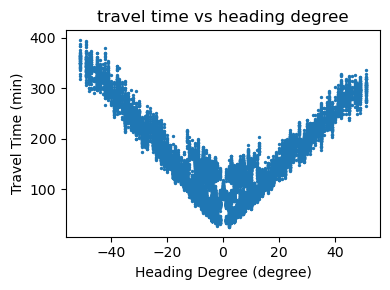

In [86]:
# ANSWER CELL

# Do not modify these lines for grading purposes
import matplotlib.pyplot as plt
from matplotlib.collections import PathCollection

# create figure and axes
fig_5, ax_5 = plt.subplots(nrows=1, ncols=1, figsize=(4,3))

# create scatter plot
plt.scatter(degree, travel_time, s=2) # SOLUTION

# Label the axes
# BEGIN SOLUTION
ax_5.set(title = 'travel time vs heading degree',
         xlabel = 'Heading Degree (degree)',
         ylabel = 'Travel Time (min)')
# END SOLUTION

# Display the plot
plt.tight_layout()
plt.show()

In [87]:
""" # BEGIN TEST CONFIG
points: 0
failure_message: Make sure to create a figure with 1 axes and assign them to "fig_5" and "ax_5".
""" # END TEST CONFIG

# Check figure was created
assert type(fig_5).__name__ == 'Figure'

# Check axes was created
assert type(ax_5).__name__ == 'Axes'

In [88]:
""" # BEGIN TEST CONFIG
points: 0
failure_message: Make sure you are plotting using plt.scatter().
""" # END TEST CONFIG

# Check scatterplot was created
assert isinstance(ax_5.collections[0], PathCollection)

In [89]:
""" # BEGIN TEST CONFIG
points: 0.25
failure_message: Make sure to plot heading degree on x-axis and travel time on y-axis.
""" # END TEST CONFIG

assert get_hash(len(ax_5.collections[0].get_offsets()[:,1])) == '73c7f51cc11fcfe48b44cf5e412fe1e4'
assert get_hash(sum(ax_5.collections[0].get_offsets()[:,1])) == 'fecc32238853cf4eb3ccb3843311bf74'
assert get_hash(len(ax_5.collections[0].get_offsets()[:,0])) == '73c7f51cc11fcfe48b44cf5e412fe1e4'
assert get_hash(sum(ax_5.collections[0].get_offsets()[:,0])) == '6474d7786064ae05c70a7535c4c1d3a0'

In [90]:
""" # BEGIN TEST CONFIG
points: 0.125
failure_message: Check x-axis label.
""" # END TEST CONFIG

# Check xlabel 
keywords = ['HEADING', 'DEGREE']
assert all(word in ax_5.get_xlabel().upper() for word in keywords)

In [91]:
""" # BEGIN TEST CONFIG
points: 0.125
failure_message: Check y-axis label.
""" # END TEST CONFIG

# Check ylabel 
keywords = ['TRAVEL', 'TIME', 'MIN']
assert all(word in ax_5.get_ylabel().upper() for word in keywords)

<font color='red'>**Question 6.2.**</font> Based on the scatter plot above, what observation can you make? Assign your answer to the variable `q6_2` as a string. (0.25 pts)

**A.** There appears to be a positive linear association between `travel_time` and `degree` \
**B.** There appears to be a negative linear association between `travel_time` and `degree` \
**C.** There appears to be no  association between `travel_time` and `degree` \
**D.** There appears to be a nonlinear association between `travel_time` and `degree`

Your answer should be a string, e.g., `"A"`, `"B"`, etc.\
Remember to put quotes around your answer choice.

**Note that the test for this question will be a hidden test. Meaning, you will NOT be able to know whether your answer is correct or not by running the `grader.check()` cell.**

In [92]:
# ANSWER CELL

q6_2 = "D" # SOLUTION
q6_2

'D'

In [93]:
""" # BEGIN TEST CONFIG
points: 0
success_message: Correct answer format. Note that the actual test is hidden.
failure_message: Incorrect answer format. Make sure you only have the letter of your answer choice in quotes.
""" # END TEST CONFIG

assert len(q6_2) == 1
assert isinstance(q6_2, str)

In [94]:
""" # BEGIN TEST CONFIG
points: 0.25
hidden: true
""" # END TEST CONFIG

assert get_hash(q6_2.upper()) == 'f623e75af30e62bbd73d6df5b50bb7b5'

It should be evident that there is a nonlinear relationship between travel time and heading degree. In the lecture, we discussed that we can still apply linear regression on **transformed data**. So, next, we will apply linear regression on a transformed set of variables.

Specifically, we will investigate two data transformations:
* Taking the square of the x values: $Y = \beta_0 + \beta_1 X^2$
* Taking the absolute value of the x values: $Y = \beta_0 + \beta_1 |X|$ 

### Data Transformation 1

In the code cell below, we will create a new variable which is simply the square of `degree` and save it as `degree_squared`.

Then, we will create a scatter plot of `travel_time` against `degree_squared` (y against x). What observations can you make based on the scatter plot? Just think of the answer. Does this look more like a linear relationship? You don't have to answer any questions. However, read and understand the code below.

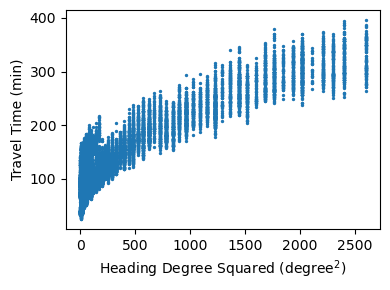

In [95]:
# transform x by squaring the values
degree_squared = degree**2

# create figure and axes
fig_6, ax_6 = plt.subplots(nrows=1, ncols=1, figsize=(4,3))

# create scatter plot
plt.scatter(degree_squared, travel_time, s=2)

# Label the axes
ax_6.set(xlabel = r'Heading Degree Squared (degree$^2$)',
         ylabel = 'Travel Time (min)')

# Display the plot
plt.tight_layout()
plt.show()

Next, we will run a linear regression model using `sm.OLS()` for the following model:

**Model 3:** $Y = \beta_0 + \beta_1 X^2$

where $Y$ is the travel time and $X$ is the heading degree.

Recall that when using `statsmodels.api.sm`, an intercept is not included by default $($i.e., $\beta_0=0)$. To include an intercept in the model, you should modify the input `x`. For example, if you are trying to perform a linear regression between `x` and `y`, you should follow these steps:
```python
x2 = sm.add_constant(x)       # to include intercept in regression
model2 = sm.OLS(y, x2).fit()  # to fit regression model
```

<font color='red'>**Question 7.0.**</font> Run a linear regression to predict `travel_time` (y) as a function of `degree_squared` (x) using `sm.OLS()`. Name this model as `model3`. Don't forget to include an intercept in your model. Then, extract the coefficient of determination, $r^2$ for this regression and assign it to `q7_0`. (0.25 pts)

*Hint: You can use the attributes  (`model3.params`, `model3.rsquared`, etc.) to extract specific outputs of the regression.*

In [96]:
# ANSWER CELL

# Modify the input x to include a constant
degree_squared2 = sm.add_constant(degree_squared) # SOLUTION

# run regression
model3 = sm.OLS(travel_time, degree_squared2).fit() # SOLUTION

# get r^2
q7_0 = model3.rsquared # SOLUTION

print(f'r^2: {q7_0:.3f}' if not isinstance(q7_0, type(Ellipsis)) else None)

r^2: 0.823


In [97]:
""" # BEGIN TEST CONFIG
points: 0.1
failure_message: Make sure you generate your model with `sm.OLS`.
""" # END TEST CONFIG

assert get_hash(type(model3)) == '3dd9afc91ae4f41fa2b9703113cf4bea'

In [98]:
""" # BEGIN TEST CONFIG
points: 0.15
failure_message: Incorrect r^2 value.
""" # END TEST CONFIG

assert get_hash(round(q7_0, 10)) == '339b84a91e46b571112da3b868868aa1'

We will next apply a second data transformation to see which data transformation gives us a better regression model.

### Data Transformation 2

In the code cell below, we will create a new variable which is simply the absolute value of `degree` and save it as `degree_abs`.

Then, we will create a scatter plot of `travel_time` against `degree_abs` (y against x). What observations can you make based on the scatter plot? *Do you expect this model to have a better fit than the previous one?* Just think of the answer. You don't have to answer any questions. However, read and understand the code below.

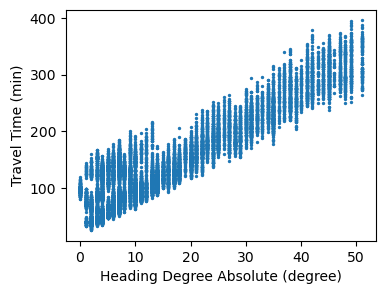

In [99]:
# transform x by taking absolute value
degree_abs = np.abs(degree)

# create figure and axes
fig_7, ax_7 = plt.subplots(nrows=1, ncols=1, figsize=(4,3))

# create scatter plot
plt.scatter(degree_abs, travel_time, s=2)

# Label the axes
ax_7.set(xlabel = 'Heading Degree Absolute (degree)',
         ylabel = 'Travel Time (min)')

plt.show()

Next, we will run a linear regression model using `sm.OLS()` for the following model:

**Model 4:** $Y = \beta_0 + \beta_1 |X|$

where $Y$ is the travel time and $X$ is the heading degree.

Recall that when using `statsmodels.api.sm`, an intercept is not included by default $($i.e., $\beta_0=0)$. To include an intercept in the model, you should modify the input `x`. For example, if you are trying to perform a linear regression between `x` and `y`, you should follow these steps:
```python
x2 = sm.add_constant(x)       # to include intercept in regression
model2 = sm.OLS(y, x2).fit()  # to fit regression model
```

<font color='red'>**Question 7.1.**</font> Run a linear regression to predict `travel_time` (y) as a function of `degree_abs` (x) using `sm.OLS()`. Name this model as `model4`. Don't forget to include an intercept in your model. Then, extract the coefficient of determination, $r^2$ for this regression and assign it to `q7_1`. (0.25 pts)

In [100]:
# ANSWER CELL

# Modify the input x to include a constant
degree_abs2 = sm.add_constant(degree_abs) # SOLUTION

# run regression
model4 = sm.OLS(travel_time, degree_abs2).fit() # SOLUTION

# get r^2
q7_1 = model4.rsquared # SOLUTION

print(f'r^2: {q7_1:.3f}' if not isinstance(q7_1, type(Ellipsis)) else None)

r^2: 0.856


In [101]:
""" # BEGIN TEST CONFIG
points: 0.1
failure_message: Make sure you generate your model with `sm.OLS`.
""" # END TEST CONFIG

assert get_hash(type(model4)) == '3dd9afc91ae4f41fa2b9703113cf4bea'

In [102]:
""" # BEGIN TEST CONFIG
points: 0.15
failure_message: Incorrect r^2 value.
""" # END TEST CONFIG

assert get_hash(round(q7_1, 10)) == '40445e80b20ccbe4e89a41bc34fd378a'

<font color='red'>**Question 7.2.**</font> Now we want to compare the performance of the two models (regression using $X^2$ versus using $|X|$). Which of the two models is better at describing the relationship between travel time and heading degree? Assign ALL that apply to the variable `q7_2`. (0.5 pts)

**A.** Model 3 (using `degree_squared`) because it has higher $r^2$ \
**B.** Model 3 (using `degree_squared`) because it has lower $r^2$\
**C.** Model 4 (using `degree_abs`) because it has higher $r^2$ \
**D.** Model 4 (using `degree_abs`) because it has lower $r^2$ \
**E.** Model 4 (using `degree_abs`) because it explains more variability in travel time \
**F.** Model 3 (using `degree_squared`) because it explains more variability in travel time \
**G.** Model 4 (using `degree_abs`) because it explains less variability in travel time \
**H.** Model 3 (using `degree_squared`) because it explains less variability in travel time

Answer in the next cell. Add each selected choice as a string and separate each two answer choices by a comma. For example, if you want to select `"A"` and `"B"`, your answer should be `"A", "B"`.\
Assign your answer to the given variable.
Remember to put quotes around each answer choice.

In [103]:
# ANSWER CELL
q7_2 = "C", "E" # SOLUTION
q7_2

('C', 'E')

In [104]:
""" # BEGIN TEST CONFIG
points: 0
success_message: Correct answer format.
failure_message: Incorrect answer format. Make sure you only have the letter of your answer choice in quotes and answers are separated by commas.
""" # END TEST CONFIG

assert isinstance(q7_2, (tuple, str))
assert all(isinstance(option, str) for option in q7_2)
assert all(len(option) == 1 for option in q7_2)

In [105]:
""" # BEGIN TEST CONFIG
points: 0.1
failure_message: Incorrect answer. Does higher or lower r2 correspond to a better fit? Which model has a higher r2?
""" # END TEST CONFIG

assert any('0d61f8370cad1d412f80b84d143e1257' == get_hash(option.upper()) for option in q7_2)

In [106]:
""" # BEGIN TEST CONFIG
points: 0.1
failure_message: Incorrect answer. 
""" # END TEST CONFIG

assert any('3a3ea00cfc35332cedf6e5e9a32e94da' == get_hash(option.upper()) for option in q7_2)

In [107]:
""" # BEGIN TEST CONFIG
points: 0.05
failure_message: Incorrect answer. Does higher or lower r2 correspond to a better fit? Which model has a higher r2?
""" # END TEST CONFIG

assert not any('7fc56270e7a70fa81a5935b72eacbe29' == get_hash(option.upper()) for option in q7_2)

In [108]:
""" # BEGIN TEST CONFIG
points: 0.05
failure_message: Incorrect answer. Does higher or lower r2 correspond to a better fit? Which model has a higher r2?
""" # END TEST CONFIG

assert not any('9d5ed678fe57bcca610140957afab571' == get_hash(option.upper()) for option in q7_2)

In [109]:
""" # BEGIN TEST CONFIG
points: 0.05
failure_message: Incorrect answer. Does higher or lower r2 correspond to a better fit? Which model has a higher r2?
""" # END TEST CONFIG

assert not any('f623e75af30e62bbd73d6df5b50bb7b5' == get_hash(option.upper()) for option in q7_2)

In [110]:
""" # BEGIN TEST CONFIG
points: 0.05
failure_message: Incorrect answer. r2 represents the fraction of the total variability in y that can be explained by the variability in x.
""" # END TEST CONFIG

assert not any('800618943025315f869e4e1f09471012' == get_hash(option.upper()) for option in q7_2)

In [111]:
""" # BEGIN TEST CONFIG
points: 0.05
failure_message: Incorrect answer. r2 represents the fraction of the total variability in y that can be explained by the variability in x.
""" # END TEST CONFIG

assert not any('dfcf28d0734569a6a693bc8194de62bf' == get_hash(option.upper()) for option in q7_2)

In [112]:
""" # BEGIN TEST CONFIG
points: 0.05
failure_message: Incorrect answer. r2 represents the fraction of the total variability in y that can be explained by the variability in x.
""" # END TEST CONFIG

assert not any('c1d9f50f86825a1a2302ec2449c17196' == get_hash(option.upper()) for option in q7_2)

### Relationship between `DELAY` and `Dep_congestion`

In this last part, you will investigate whether there is an association between time spent before taking off (gate delay, taxi time, etc.), `DELAY`, and the congestion ratio at the departure airport, `Dep_congestion`. It is reasonable to expect that if the departure airport is congested and operating close or at its capacity, this will cause delays in the departure. So we will investigate if this association actually exists.

If there is no association between `DELAY` and `Dep_congestion`, then $\beta_1$ in the equation below should be 0:

$\text{DELAY} = \beta_0+\beta_1\times \text{Dep\_congestion}$

So, our hypotheses are:

**$H_0: \beta_1 = 0$** (no relationship)

**$H_1: \beta_1 \neq 0$**

Using `sm.OLS()`, we can obtain the test statistic, $p$-value, as well as the confidence interval for $\beta_1$ based on our sample. So, let's run a regression between `DELAY` and `Dep_congestion`.

<font color='red'>**Question 8.0.**</font> Let's first take the relevant columns for `DELAY` and `Dep_congestion` from the DataFrame you loaded above and save them as `delay` and `cong`, respectively. We will need to use these vectors for the linear regression. (0.25 pts)

In [113]:
# ANSWER CELL

# create variables for delay and congestion
delay = df.DELAY # SOLUTION
cong = df.Dep_congestion # SOLUTION

In [114]:
""" # BEGIN TEST CONFIG
points: 0.125
failure_message: Incorrect delay vector.
""" # END TEST CONFIG

assert get_hash(len(delay)) == '73c7f51cc11fcfe48b44cf5e412fe1e4'
assert get_hash(sum(delay)) == 'b69f378b8b00e843f4b677aa57fe4ec5'

In [115]:
""" # BEGIN TEST CONFIG
points: 0.125
failure_message: Incorrect cong vector.
""" # END TEST CONFIG

assert get_hash(len(cong)) == '73c7f51cc11fcfe48b44cf5e412fe1e4'
assert get_hash(round(sum(cong), 5)) == '642797861dfc092c80f909f421eda821'

Next, we will run a linear regression to predict `delay` as a function of  `cong` using `sm.OLS()`.

<font color='red'>**Question 8.1.**</font> Run a linear regression to predict `delay` (y) as a function of `cong` (x) using `sm.OLS()`. Name this model as `model5`. Don't forget to include an intercept in your model. Then, extract the coefficient of determination, $r^2$, for this regression and assign it to `q8_1`. (0.5 pts)

In [116]:
# ANSWER CELL

# Modify the input x to include a constant
cong2 = sm.add_constant(cong) # SOLUTION

# run regression
model5 = sm.OLS(delay, cong2).fit() # SOLUTION

# get r^2
q8_1 = model5.rsquared # SOLUTION

print(f'r^2: {q8_1:.3f}' if not isinstance(q8_1, type(Ellipsis)) else None)

r^2: 0.018


In [117]:
""" # BEGIN TEST CONFIG
points: 0.1
failure_message: Make sure you generate your model with `sm.OLS`.
""" # END TEST CONFIG

assert get_hash(type(model5)) == '3dd9afc91ae4f41fa2b9703113cf4bea'

In [118]:
""" # BEGIN TEST CONFIG
points: 0.4
failure_message: Incorrect r^2 value.
""" # END TEST CONFIG

assert get_hash(round(q8_1, 10)) == '06082ca98be60f9d0a3154ec84b3940c'

As previously mentioned, `sm.OLS()` computes the test statistic, $p$-value, as well as the confidence interval for $\beta_1$ based on our sample.

To view these outputs, run `model5.summary()` in the code cell below, which returns a full summary of the regression. 

In the output table, search for the row corresponding to `Dep_congestion` (should be 12th row in the summary table). 
* The first value in that row under `coef` is the estimated slope $\hat{\beta_1}$ (look at the row corresponding to `Dep_congestion` and NOT `const`).
* The second value in that row under `std error` is the standard deviation in $\hat{\beta_1}$. 
* The third value in that row under `t` is the observed $t$-statistic corresponding to the hypothesis test.
* The fourth value in that row under `P>|t|` is the $p$-value corresponding to the hypothesis test.
* The fifth and sixth values in that row under `[0.025  0.975]` are the lower and upper values of the 95% confidence interval on $\beta_1$.


In [119]:
# output an overall summary
model5.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  DELAY   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     340.3
Date:                Thu, 22 May 2025   Prob (F-statistic):           2.51e-75
Time:                        19:24:38   Log-Likelihood:                -73680.
No. Observations:               18936   AIC:                         1.474e+05
Df Residuals:                   18934   BIC:                         1.474e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             14.8698      0.188     79.047      0.000      14.501      15.239
Dep_congestion     4.8400      0.262     18.447      0.000       4.326       5.354
==============================================================================
Omnibus:                     3330.991   Durbin-Watson:                   1.999
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             5474.123
Skew:                           1.198   Prob(JB):                         0.00
Kurtosis:                       4.094   Cond. No.                         4.39
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<font color='red'>**Question 8.2.**</font> Based on the regression output, does there appear to be an association between departure delay and congestion ratio at the airport? Use a 0.05 significance level. Assign ALL that apply to the variable `q8_2`. (1.0 pt)

**A.** There $\underline{\text{isn't an association}}$ because the $\underline{\text{p-value is greater than 0.05}}$ \
**B.** There $\underline{\text{isn't an association}}$ because the null hypothesis value (0) is $\underline{\text{within the confidence interval}}$ \
**C.** There $\underline{\text{is an association}}$ because the null hypothesis value (0) is $\underline{\text{not within the confidence interval}}$ \
**D.** There $\underline{\text{is an association}}$ because the $\underline{\text{p-value is less than 0.05}}$ \
**E.** There $\underline{\text{isn't an association}}$ because the $\underline{\text{p-value is less than 0.05}}$ \
**F.** There $\underline{\text{isn't association}}$ because the null hypothesis value (0) is $\underline{\text{not within the confidence interval}}$


Answer in the next cell. Add each selected choice as a string and separate each two answer choices by a comma. For example, if you want to select `"A"` and `"B"`, your answer should be `"A", "B"`.\
Assign your answer to the given variable.
Remember to put quotes around each answer choice.

**Note that the test for this question will be a hidden test. Meaning, you will NOT be able to know whether your answer is correct or not by running the `grader.check()` cell. You should know how to confidently answer this question by now.**

In [120]:
# ANSWER CELL

q8_2 = "C", "D" # SOLUTION
q8_2

('C', 'D')

In [121]:
""" # BEGIN TEST CONFIG
points: 0
success_message: Correct answer format. Note that the actual test is hidden.
failure_message: Incorrect answer format. Make sure you only have the letter of your answer choice in quotes and answers are separated by commas.
""" # END TEST CONFIG

assert isinstance(q8_2, (tuple, str))
assert all(isinstance(option, str) for option in q8_2)
assert all(len(option) == 1 for option in q8_2)

In [122]:
""" # BEGIN TEST CONFIG
points: 0.1
hidden: true
""" # END TEST CONFIG

assert get_hash("A" in q8_2 or "a" in q8_2) == 'f8320b26d30ab433c5a54546d21f414c'

In [123]:
""" # BEGIN TEST CONFIG
points: 0.1
hidden: true
""" # END TEST CONFIG

assert get_hash("B" in q8_2 or "b" in q8_2) == 'f8320b26d30ab433c5a54546d21f414c'

In [124]:
""" # BEGIN TEST CONFIG
points: 0.3
hidden: true
""" # END TEST CONFIG

assert get_hash("C" in q8_2 or "c" in q8_2) == 'f827cf462f62848df37c5e1e94a4da74'

In [125]:
""" # BEGIN TEST CONFIG
points: 0.3
hidden: true
""" # END TEST CONFIG

assert get_hash("D" in q8_2 or "d" in q8_2) == 'f827cf462f62848df37c5e1e94a4da74'

In [126]:
""" # BEGIN TEST CONFIG
points: 0.1
hidden: true
""" # END TEST CONFIG

assert get_hash("E" in q8_2 or "e" in q8_2) == 'f8320b26d30ab433c5a54546d21f414c'

In [127]:
""" # BEGIN TEST CONFIG
points: 0.1
hidden: true
""" # END TEST CONFIG

assert get_hash("F" in q8_2 or "f" in q8_2) == 'f8320b26d30ab433c5a54546d21f414c'

### You're done with this Lab!

**Important submission information:** After completing the assignment, click on the Save icon from the Tool Bar &nbsp;<i class="fa fa-save" style="font-size:16px;"></i>&nbsp;. After saving your notebook, **run the cell with** `grader.check_all()` and confirm that you pass the same tests as in the notebook. Then, **run the final cell** `grader.export()` and click the link to download the zip file. Finally, go to Gradescope and submit the zip file to the corresponding assignment. 

**Once you have submitted, stay on the Gradescope page to confirm that you pass the same tests as in the notebook.**

Congratulations on finishing CE93 labs!


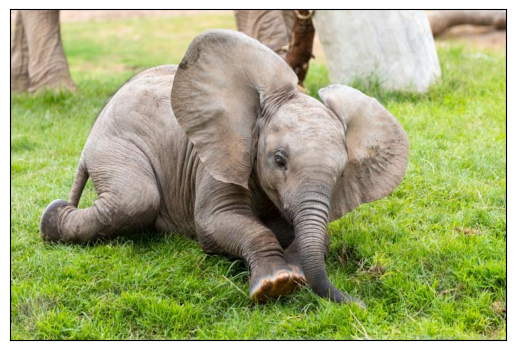

<IPython.core.display.Javascript object>

In [128]:
%matplotlib inline
from IPythonDisplayFireworks import Fireworks
from IPython.display import clear_output
img = mpimg.imread('resources/animal.jpg')
imgplot = plt.imshow(img)
imgplot.axes.get_xaxis().set_visible(False)
imgplot.axes.get_yaxis().set_visible(False)
print("Congratulations on finishing CE93 labs!")
plt.show()
Fireworks(30)

from IPython.display import display, Javascript

# Define the JavaScript code to scroll to the section header
scroll_to_section_header_js = """
var section_header = document.getElementById('section_header');
if (section_header) {
    section_header.scrollIntoView({ behavior: 'smooth', block: 'start' });
} else {
    console.error('Section header not found.');
}
"""

# Execute the JavaScript code
display(Javascript(scroll_to_section_header_js))